In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import tempo
import numpy as np 
import pandas as pd
import anndata
import torch


# --- MATPLOTLIB SETTINGS ---
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
rc_params = {
	"font.family": "sans-serif", # "text.usetex": True,
	"font.serif" : ['Arial'], # "font.size" : 6,
	"font.weight" : "normal",
	'xtick.labelsize' : 5,
	'ytick.labelsize' : 5,
	'legend.fontsize' : 5,
	'axes.labelsize' : 6,
	'axes.linewidth': 0.8,
	'lines.linewidth' : 1
}
matplotlib.rcParams.update(rc_params)
margins = {  #     vvv margin in inches
	"left"   :     0.2,
	'right' : 1.0,
	'bottom' : 0.15
}

method_color_map = {'tempo' : 'r', 'cyclops' : 'b', 'cyclum' : 'g', 'pca' : 'y', 'random' : 'k', 'optimal' : 'k'}
method_linestyle_map = {'tempo' : '-', 'cyclops' : '-', 'cyclum' : '-', 'pca' : '-', 'random' : '--', 'optimal' : ":"}

import power_spherical
from tempo import objective_functions


/Users/mingyaolab/opt/anaconda3/envs/misalignment/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- INIT ---

# adata_path = '/Users/benauerbach/Dropbox/tempo_paper/sub_2_analyses/non_sinusoid_analyses/adata.h5ad'
# cell_posterior_path = '/Users/benauerbach/Dropbox/tempo_paper/sub_2_analyses/non_sinusoid_analyses/tempo_res/tempo_results/0/cell_phase_estimation/cell_posterior.tsv'
# hvg_gene_posterior_path = '/Users/benauerbach/Dropbox/tempo_paper/sub_2_analyses/non_sinusoid_analyses/tempo_res/tempo_results/0/de_novo_cycler_id/gene_prior_and_posterior.tsv'
# clock_gene_unprepped_param_path = '/Users/benauerbach/Dropbox/tempo_paper/sub_2_analyses/non_sinusoid_analyses/tempo_res/tempo_results/0/cell_phase_estimation/optimal_gene_params_unprepped.pt'
# clock_gene_param_df_path = '/Users/benauerbach/Dropbox/tempo_paper/sub_2_analyses/non_sinusoid_analyses/tempo_res/tempo_results/0/cell_phase_estimation/gene_prior_and_posterior.tsv'

# num_gene_samples = 10
# previous_de_novo_cycler_folder_out = '/users/benauerbach/desktop/testing'
# use_nb = False
# log_mean_log_disp_coef = None




# adata_path = '/Users/benauerbach/Dropbox/tempo_paper/figures/ld_figure/fitzgerald_cluster-1/adata.h5ad'
# cell_posterior_path = '/Users/benauerbach/Dropbox/tempo_paper/figures/ld_figure/fitzgerald_cluster-1/tempo/tempo_results/0/cell_phase_estimation/cell_posterior.tsv'
# hvg_gene_posterior_path = '/Users/benauerbach/Dropbox/tempo_paper/figures/ld_figure/fitzgerald_cluster-1/tempo/tempo_results/0/de_novo_cycler_id/gene_prior_and_posterior.tsv'
# clock_gene_unprepped_param_path = '/Users/benauerbach/Dropbox/tempo_paper/figures/ld_figure/fitzgerald_cluster-1/tempo/tempo_results/0/cell_phase_estimation/optimal_gene_params_unprepped.pt'
# clock_gene_param_df_path = '/Users/benauerbach/Dropbox/tempo_paper/figures/ld_figure/fitzgerald_cluster-1/tempo/tempo_results/0/cell_phase_estimation/gene_prior_and_posterior.tsv'
# num_gene_samples = 10
# previous_de_novo_cycler_folder_out = '/users/benauerbach/desktop/fibroblast_tempo2_de_novo_id'
# use_nb = True
# log_mean_log_disp_coef= [-1.875966310501098633e+00,
# -7.077424973249435425e-02]





# adata_path = '/Users/benauerbach/Dropbox/tempo_paper/figures/ld_figure/fitzgerald_cluster-0/adata.h5ad'
# cell_posterior_path = '/Users/benauerbach/Dropbox/tempo_paper/figures/ld_figure/fitzgerald_cluster-0/tempo/tempo_results/0/cell_phase_estimation/cell_posterior.tsv'
# hvg_gene_posterior_path = '/Users/benauerbach/Dropbox/tempo_paper/figures/ld_figure/fitzgerald_cluster-0/tempo/tempo_results/0/de_novo_cycler_id/gene_prior_and_posterior.tsv'
# clock_gene_unprepped_param_path = '/Users/benauerbach/Dropbox/tempo_paper/figures/ld_figure/fitzgerald_cluster-0/tempo/tempo_results/0/cell_phase_estimation/optimal_gene_params_unprepped.pt'
# clock_gene_param_df_path = '/Users/benauerbach/Dropbox/tempo_paper/figures/ld_figure/fitzgerald_cluster-0/tempo/tempo_results/0/cell_phase_estimation/gene_prior_and_posterior.tsv'
# num_gene_samples = 10
# previous_de_novo_cycler_folder_out = '/users/benauerbach/desktop/smc_tempo2_de_novo_id'
# use_nb = True
# log_mean_log_disp_coef = [-3.613810777664184570e+00,
# -1.803428083658218384e-01]








head_folder_path = '/Users/benauerbach/Dropbox/tempo_paper/sub_2_analyses/non_sinusoid_analyses_true_cyclers'
adata_path = '%s/adata.h5ad' % head_folder_path
cell_posterior_path = '%s/tempo_res/tempo_results/0/cell_phase_estimation/cell_posterior.tsv' % head_folder_path
hvg_gene_posterior_path = '/Users/benauerbach/Dropbox/tempo_paper/sub_2_analyses/non_sinusoid_analyses_true_cyclers/tempo_res/tempo_results/0/de_novo_cycler_id/gene_prior_and_posterior.tsv'
clock_gene_unprepped_param_path = '/Users/benauerbach/Dropbox/tempo_paper/sub_2_analyses/non_sinusoid_analyses_true_cyclers/tempo_res/tempo_results/0/cell_phase_estimation/optimal_gene_params_unprepped.pt'
clock_gene_param_df_path = '/Users/benauerbach/Dropbox/tempo_paper/sub_2_analyses/non_sinusoid_analyses_true_cyclers/tempo_res/tempo_results/0/cell_phase_estimation/gene_prior_and_posterior.tsv'
num_gene_samples = 10
previous_de_novo_cycler_folder_out = '/users/benauerbach/desktop/non_sinusoid_true_cycler_tempo2_de_novo_id'
use_nb = False
log_mean_log_disp_coef = None







# alg params 
num_grid_points = 24



In [3]:
# --- LOAD THE PHASE POSTERIOR OBJECT ---

import torch
from tempo import cell_posterior

clock_cell_posterior_df = pd.read_table(cell_posterior_path,sep='\t',index_col='barcode')
clock_cell_posterior = torch.Tensor(np.array(clock_cell_posterior_df))
clock_posterior_obj = tempo.cell_posterior.ThetaPosteriorDist(clock_cell_posterior)





FileNotFoundError: [Errno 2] No such file or directory: '/Users/benauerbach/Dropbox/tempo_paper/sub_2_analyses/non_sinusoid_analyses_true_cyclers/tempo_res/tempo_results/0/cell_phase_estimation/cell_posterior.tsv'

In [113]:
# --- LOAD ADATA ---

adata = anndata.read_h5ad(adata_path)
adata


AnnData object with n_obs × n_vars = 4800 × 19065
    obs: 'CT', 'phase', 'lib_size', 'log_L'
    var: 'prop', 'fft_circ_amp_fraction', 'is_cycler', 'CycID', 'BH.Q', 'ADJ.P', 'PER', 'LAG', 'AMP'

In [114]:
# --- LOAD THE DE NOVO RESULTS ---

# ** load the df's that we need **

# load min max df
min_max_fileout = '%s/log_min_max.tsv' % previous_de_novo_cycler_folder_out # % (folder_out)
min_max_df = pd.read_table(min_max_fileout,sep='\t',index_col='gene')

# load non-flat log alpha df
non_flat_param_log_alpha_fileout = '%s/non_flat_log_alpha.tsv' % previous_de_novo_cycler_folder_out # % (folder_out)
non_flat_param_log_alpha_df = pd.read_table(non_flat_param_log_alpha_fileout,sep='\t',index_col='gene')

# load non-flat log beta df
non_flat_param_log_beta_fileout = '%s/non_flat_log_beta.tsv' % previous_de_novo_cycler_folder_out # % (folder_out)
non_flat_param_log_beta_df = pd.read_table(non_flat_param_log_beta_fileout,sep='\t',index_col='gene')

# load de novo metric df
de_novo_result_fileout = '%s/de_novo_results.tsv' % previous_de_novo_cycler_folder_out # % (folder_out)
de_novo_result_df = pd.read_table(de_novo_result_fileout,sep='\t',index_col='gene')

# ** limit the df's to the de novo cylers **
de_novo_cyclers = list(de_novo_result_df[de_novo_result_df['is_de_novo']].index)
de_novo_min_max_df = min_max_df.loc[de_novo_cyclers]
de_novo_param_log_alpha_df = non_flat_param_log_alpha_df.loc[de_novo_cyclers]
de_novo_param_log_beta_df = non_flat_param_log_beta_df.loc[de_novo_cyclers]
de_novo_result_df = de_novo_result_df.loc[de_novo_cyclers]

# de_novo_result_df = de_novo_result_df[de_novo_result_df['log10_bf'] >= 200]
# de_novo_result_df = de_novo_result_df[(de_novo_result_df['log10_bf'] >= 2) & (de_novo_result_df['expected_molecule_dif'] >= 1) & (de_novo_result_df['fft_circadian_fraction'] >= 0.25)]
# de_novo_cyclers = list(de_novo_result_df.index)
# de_novo_min_max_df = min_max_df.loc[de_novo_cyclers]
# de_novo_param_log_alpha_df = non_flat_param_log_alpha_df.loc[de_novo_cyclers]
# de_novo_param_log_beta_df = non_flat_param_log_beta_df.loc[de_novo_cyclers]



de_novo_result_df


,log10_bf,expected_molecule_dif,fft_circadian_fraction,is_de_novo
gene,,,,
Acly,353.797730,0.884322,0.250338,True
Acta1,180.935820,1.120597,0.235720,True
Angptl4,154.510010,0.521667,0.258073,True
Atp2a1,180.355410,0.822957,0.295743,True
Cdkn1a,211.208770,0.738205,0.312705,True
Cyp2e1,1494.634200,1.516394,0.248080,True
Eln,324.063840,1.183039,0.235415,True
Fmo2,362.519260,1.123634,0.248172,True
Fmo3,227.711320,0.634625,0.250668,True


In [115]:
# --- LOAD CLOCK RESULTS ---


clock_gene_param_df = pd.read_table(clock_gene_param_df_path,sep='\t',index_col='gene')
clock_genes = list(clock_gene_param_df.index)



In [116]:
# --- INPUTS WE NEED ---



# ** log_L **
log_L = torch.log(torch.Tensor(np.array(adata.obs['lib_size'])))


# ** de novo X **
try:
    de_novo_X = torch.Tensor(np.array(adata[:,de_novo_cyclers].X.todense()))
except:
    de_novo_X = torch.Tensor(adata[:,de_novo_cyclers].X.todense())


# ** clock X **
try:
    clock_X = torch.Tensor(np.array(adata[:,clock_genes].X.todense()))
except:
    clock_X = torch.Tensor(adata[:,clock_genes].X.todense())

    
    
# ** de novo params **
de_novo_log_alpha = torch.nn.Parameter(torch.Tensor(np.array(de_novo_param_log_alpha_df.T)),requires_grad=True)
de_novo_log_beta = torch.nn.Parameter(torch.Tensor(np.array(de_novo_param_log_beta_df.T)),requires_grad=True)
de_novo_min_log_prop = torch.Tensor(np.array(de_novo_min_max_df['log_min']))
de_novo_max_log_prop = torch.Tensor(np.array(de_novo_min_max_df['log_max']))
de_novo_prior_alpha = torch.ones((de_novo_X.shape[1],num_grid_points))
de_novo_prior_beta = torch.ones((de_novo_X.shape[1],num_grid_points))



# ** clock params **
clock_param_dict = torch.load(clock_gene_unprepped_param_path)
for key, val in clock_param_dict.items():
    clock_param_dict[key] = torch.nn.Parameter(clock_param_dict[key],requires_grad=True)
clock_min_amp = 0
# clock_max_amp = 3.4538776394910684
clock_max_amp = 2.5

# ** prior theta euclid dist **
prior_theta_euclid_dist = power_spherical.HypersphericalUniform(dim = 2)







In [117]:
# --- DEFINE FN'S TO COMPUTE LIKELIHOOD MAT'S FOR DE NOVO AND CLOCK GENES ---


# [num_gene_samples x num_cells x num_cell_samples x num_genes]
def compute_nonparametric_ll_mat(gene_X,
                            log_L,
                            phases_sampled,
                            gene_log_alpha,
                            gene_log_beta,
                            gene_min_log_prop,
                            gene_max_log_prop,
                            num_gene_samples,
                            use_nb,
                            log_mean_log_disp_coef):
    
    
    # ** get num grid points from de_novo_log_alpha **
    num_grid_points = gene_log_alpha.shape[0]


    # ** discretize the cell phases **
    phases_discretized_indices = torch.round((phases_sampled / (2 * np.pi)) * num_grid_points) # convert [0,1] to [0,num_grid_points] (float), and then discretize
    phases_discretized_indices[torch.where(phases_discretized_indices == num_grid_points)] = 0 # since bins actually go from [0,num_grid_points - 1], let's wrap back around
    phases_discretized_indices = phases_discretized_indices.int().long() # [num_cells x num_cell_samples]


    # ** get the cell-gene alpha and beta's ** 
    cell_gene_alpha = torch.exp(gene_log_alpha)[phases_discretized_indices.long(),:] # [num_cells x num_cell_samples x num_genes]
    cell_gene_beta = torch.exp(gene_log_beta)[phases_discretized_indices.long(),:] # [num_cells x num_cell_samples x num_genes]

    # **  get the corresponding distribution
    cell_gene_dist = torch.distributions.beta.Beta(cell_gene_alpha,cell_gene_beta)

    # ** sample gene proportions: [num_gene_samples x num_cells x num_cell_samples x num_genes] ** 
    cell_gene_log_prop_sampled = cell_gene_dist.rsample((num_gene_samples,)) # [num_]
    cell_gene_log_prop_sampled = cell_gene_log_prop_sampled * (gene_max_log_prop.unsqueeze(0).unsqueeze(0) - gene_min_log_prop.unsqueeze(0).unsqueeze(0)) + gene_min_log_prop.unsqueeze(0).unsqueeze(0) # put in [min to max prop for each gene]


    # **  get the cell_gene_log_mean (expected log prop scaled by the library size): [num_gene_samples x num_cells x num_cell_samples x num_genes] ** 
    cell_gene_log_mean = cell_gene_log_prop_sampled + log_L.unsqueeze(0).unsqueeze(2).unsqueeze(2)
    cell_gene_mean = torch.exp(cell_gene_log_mean)

    #  ** compute the MC expected log likelihood for gene: # [num_gene_samples x num_cells x num_cell_samples x num_genes] ** 
    gene_X_reshaped = gene_X.unsqueeze(0).unsqueeze(2)
    if use_nb:
        ll_mat = objective_functions.compute_nb_ll(gene_X_reshaped,
        cell_gene_log_prop_sampled,
        cell_gene_log_mean,
        log_mean_log_disp_coef)
    else:
        ll_mat = torch.distributions.poisson.Poisson(cell_gene_mean).log_prob(gene_X_reshaped)
        
    return ll_mat
    


# [num_gene_samples x num_cells x num_cell_samples x num_genes]
def compute_clock_ll_mat(clock_X,
                        log_L,
                        clock_param_dict,
                        clock_min_amp,
                        clock_max_amp,
                        phases_sampled,
                        num_gene_samples,
                        use_nb,
                        log_mean_log_disp_coef):
    


    
    # ** reshape phases sampled: [1 x num_cells x num_cell_samples x 1]**
    phases_sampled = phases_sampled.unsqueeze(0).unsqueeze(3)
    
    # ** clock distributions **
    from tempo import utils
    clock_distrib_dict = tempo.utils.init_distributions_from_param_dicts(
        gene_param_dict = clock_param_dict,
        min_amp = clock_min_amp,
        max_amp = clock_max_amp,
        prep = True)

    
    #  ** sample parameters: [num_gene_samples x 1 x 1 x num_genes] ** 
    mu_sampled = clock_distrib_dict['mu'].rsample((num_gene_samples,)).unsqueeze(1).unsqueeze(2)
    A_sampled = clock_distrib_dict['A'].rsample((num_gene_samples,)).unsqueeze(1).unsqueeze(2)
    phi_euclid_sampled = clock_distrib_dict['phi_euclid'].rsample((num_gene_samples,))
    phi_sampled = torch.atan2(phi_euclid_sampled[:,:,1],phi_euclid_sampled[:,:,0]).unsqueeze(1).unsqueeze(2)
    Q_sampled = clock_distrib_dict['Q_prob'].rsample((num_gene_samples,)).unsqueeze(1).unsqueeze(2)

    
    
    # **  get corresponding samples for log prop's: [num_gene_samples x num_cells x num_cell_samples x num_genes] ** 
    if Q_sampled is None:
        clock_log_prop_sampled = mu_sampled + (A_sampled * torch.cos(phases_sampled - phi_sampled))
    else:
        clock_log_prop_sampled = mu_sampled + (Q_sampled * A_sampled * torch.cos(phases_sampled - phi_sampled))

    
    #  ** get corresponding samples for log means: [num_gene_samples x num_cells x num_cell_samples x num_genes] ** 
    clock_log_mean_sampled = clock_log_prop_sampled + log_L.unsqueeze(0).unsqueeze(2).unsqueeze(3)


    # ** compute the LL **
    if use_nb:
        ll_mat = objective_functions.compute_nb_ll(clock_X.unsqueeze(0).unsqueeze(2),
            clock_log_prop_sampled,
            clock_log_mean_sampled,
            log_mean_log_disp_coef)

    else:
        ll_mat = torch.distributions.poisson.Poisson(rate = torch.exp(clock_log_mean_sampled)).log_prob(clock_X.unsqueeze(0).unsqueeze(2))
    
    return ll_mat

    
    
    




In [118]:
# --- TEST OUT FN'S TO COMPUTE LIKELIHOOD MAT'S FOR DE NOVO AND CLOCK GENES ---



from tempo import objective_functions

# phases sampled
phases_sampled = torch.arange(0,2*np.pi,(2 * np.pi) / 12).unsqueeze(0)
# phases_sampled = cell_posterior_obj.sample(5)


# [num_gene_samples x num_cells x num_cell_samples x num_genes]
de_novo_ll_mat = compute_nonparametric_ll_mat(gene_X = de_novo_X,
                            log_L = log_L,
                            phases_sampled = phases_sampled,
                            gene_log_alpha = de_novo_log_alpha,
                            gene_log_beta = de_novo_log_beta,
                            gene_min_log_prop = de_novo_min_log_prop,
                            gene_max_log_prop = de_novo_max_log_prop,
                            num_gene_samples = num_gene_samples,
                            use_nb = use_nb,
                            log_mean_log_disp_coef = log_mean_log_disp_coef)

# [num_gene_samples x num_cells x num_cell_samples x num_genes]
clock_ll_mat = compute_clock_ll_mat(clock_X = clock_X,
                        clock_param_dict = clock_param_dict,
                        clock_min_amp = clock_min_amp,
                        clock_max_amp = clock_max_amp,
                        log_L = log_L,
                        phases_sampled = phases_sampled,
                        num_gene_samples = num_gene_samples,
                        use_nb = use_nb,
                        log_mean_log_disp_coef = log_mean_log_disp_coef)




In [119]:
# --- DEFINE FUNCTION TO ESTIMATE POSTERIOR ---



import hyperspherical_vae
def grid_sample_posterior_cell_phase(log_L,
    prior_theta_euclid_dist,
    num_grid_points = 12,
    num_gene_samples = 5,
    clock_X = None,
    clock_param_dict = None,
    clock_min_amp = None,
    clock_max_amp = None,
    de_novo_X = None,
    de_novo_log_alpha = None,
    de_novo_log_beta = None,
    de_novo_min_log_prop = None,
    de_novo_max_log_prop = None,                             
    use_nb = False,
    log_mean_log_disp_coef = None
    ):

    
    # --- IF CHECK IF WE ARE USING THE CLOCK AND/OR THE DE NOVO IN THE LIKELIHOOD ---
    use_clock_ll = (clock_X is not None) & (clock_param_dict is not None) & (clock_min_amp is not None) & (clock_max_amp is not None)
    use_de_novo_ll = (de_novo_X is not None) & (de_novo_log_alpha is not None) & (de_novo_log_beta is not None) & (de_novo_min_log_prop is not None) & (de_novo_max_log_prop is not None)
    if not use_clock_ll and not use_de_novo_ll:
        raise Exception("Error: neither clock nor de novo genes given as input for grid sampling.")
    

    # --- GET THE PHASE GRID: [1 x num_grid_points] ----
    phase_grid = torch.arange(0,2*np.pi,(2 * np.pi) / num_grid_points)
    phase_grid_euclid = torch.zeros((num_grid_points,2))
    phase_grid_euclid[:,0] = torch.cos(phase_grid)
    phase_grid_euclid[:,1] = torch.sin(phase_grid)


    
    
    
    

    # --- GET THE LL MAT FOR THE DE NOVO AND CLOCK GENES ---- **

    # [num_gene_samples x num_cells x num_cell_samples x num_genes]
    if use_de_novo_ll:
        de_novo_ll_mat = compute_nonparametric_ll_mat(gene_X = de_novo_X,
                                    log_L = log_L,
                                    phases_sampled = phase_grid.unsqueeze(0),
                                    gene_log_alpha = de_novo_log_alpha,
                                    gene_log_beta = de_novo_log_beta,
                                    gene_min_log_prop = de_novo_min_log_prop,
                                    gene_max_log_prop = de_novo_max_log_prop,
                                    num_gene_samples = num_gene_samples,
                                    use_nb = use_nb,
                                    log_mean_log_disp_coef = log_mean_log_disp_coef)

    # [num_gene_samples x num_cells x num_cell_samples x num_genes]
    if use_clock_ll:
        clock_ll_mat = compute_clock_ll_mat(clock_X = clock_X,
                                clock_param_dict = clock_param_dict,
                                clock_min_amp = clock_min_amp,
                                clock_max_amp = clock_max_amp,
                                log_L = log_L,
                                phases_sampled = phase_grid.unsqueeze(0),
                                num_gene_samples = num_gene_samples,
                                use_nb = use_nb,
                            log_mean_log_disp_coef = log_mean_log_disp_coef)




    # --- CONCATENATE THE CLOCK AND DE NOVO LIKELIHOODS IF WE NEED TO ---
    
    if use_de_novo_ll and use_clock_ll:
        # [num_gene_samples x num_cells x num_cell_samples x (num_clock_genes + num_de_novo_genes)]
        ll_cell_gene_grid_sampled = torch.cat((clock_ll_mat,de_novo_ll_mat), dim=3)
    elif use_de_novo_ll:
        # [num_gene_samples x num_cells x num_cell_samples x num_de_novo_genes]
        ll_cell_gene_grid_sampled = de_novo_ll_mat
    else:
        # [num_gene_samples x num_cells x num_cell_samples x num_clock_genes]
        ll_cell_gene_grid_sampled = clock_ll_mat


    # --- COMPUTE THE PHASE LIKELIHOODS: [num_cells x num_grid_points]---

    phase_ll_un_norm = torch.mean(torch.sum(ll_cell_gene_grid_sampled,dim=3),dim=0) # [num_cells x num_grid_points]
    phase_ll_max_norm = phase_ll_un_norm - torch.max(phase_ll_un_norm,axis=1).values.unsqueeze(1)
    phase_ll_max_norm = phase_ll_max_norm.to(torch.float64)
    phase_likelihood_max_norm = torch.exp(phase_ll_max_norm)
    phase_likelihood = phase_likelihood_max_norm / torch.sum(phase_likelihood_max_norm,axis=1).unsqueeze(1)
    phase_ll = torch.log(phase_likelihood)


    # --- COMPUTE THE PRIOR PROBABILITIES OVER THETA GRID: # [1 x num_grid_points] or [num_cells x num_grid_points]---

    if prior_theta_euclid_dist is not None:
        if prior_theta_euclid_dist.__class__ == power_spherical.distributions.HypersphericalUniform:
            prior_theta_grid_ll_un_norm = prior_theta_euclid_dist.log_prob(phase_grid_euclid).unsqueeze(0) #[1 x num_grid_points]     
        elif prior_theta_euclid_dist.__class__ == hyperspherical_vae.distributions.von_mises_fisher.VonMisesFisher:
            prior_theta_grid_ll_un_norm = prior_theta_euclid_dist.log_prob(phase_grid_euclid.unsqueeze(1)).T #[num_cells x num_grid_points]    
        elif prior_theta_euclid_dist.__class__ == cell_posterior.ThetaPosteriorDist:
            prior_theta_grid_ll_un_norm = prior_theta_euclid_dist.log_prob(phase_grid.unsqueeze(1)).T #[num_cells x num_grid_points]            
        else:
            raise Exception("Cell prior distribution choice not recognized.")
    prior_theta_grid_ll_max_norm = prior_theta_grid_ll_un_norm - torch.max(prior_theta_grid_ll_un_norm,dim=1).values.unsqueeze(1)
    prior_theta_grid_ll_max_norm = prior_theta_grid_ll_max_norm.to(torch.float64)
    prior_theta_grid_likelihood_max_norm = torch.exp(prior_theta_grid_ll_max_norm)
    prior_theta_grid_likelihood = prior_theta_grid_likelihood_max_norm / torch.sum(prior_theta_grid_likelihood_max_norm,dim=1).unsqueeze(1)
    prior_phase_ll = torch.log(prior_theta_grid_likelihood)




    
    
    

    # ---- COMPUTE THE PHASE POSTERIOR (AVERAGING THE INDIVIDAUL SAMPLE PHASE POSTERIORS) ----
    posterior_phase_ll_un_norm = phase_ll + prior_phase_ll
    posterior_phase_ll_max_norm = posterior_phase_ll_un_norm - torch.max(posterior_phase_ll_un_norm,axis=1).values.unsqueeze(1)
    posterior_phase_ll_max_norm = posterior_phase_ll_max_norm.to(torch.float64)
    posterior_phase_likelihood_max_norm = torch.exp(posterior_phase_ll_max_norm)
    posterior_phase_likelihood = posterior_phase_likelihood_max_norm / torch.sum(posterior_phase_likelihood_max_norm,axis=1).unsqueeze(1)




    return posterior_phase_likelihood, phase_likelihood, prior_theta_grid_likelihood




In [120]:
# --- TEST OUT THE GRID SAMPLING ---

# # ** just use de novo in LL and use the clock as a prior **
# posterior_phase_likelihood, phase_likelihood, prior_theta_grid_likelihood = grid_sample_posterior_cell_phase(log_L,
#     clock_posterior_obj,
#     num_grid_points = 12,
#     num_gene_samples = 5,
#     clock_X = None,
#     clock_param_dict = None,
#     clock_min_amp = None,
#     clock_max_amp = None,
#     de_novo_X = de_novo_X,
#     de_novo_log_alpha = de_novo_log_alpha,
#     de_novo_log_beta = de_novo_log_beta,
#     de_novo_min_log_prop = de_novo_min_log_prop,
#     de_novo_max_log_prop = de_novo_max_log_prop,                             
#     use_nb = False,
#     log_mean_log_disp_coef = None)


# ** use non-informative prior and de novo + clock **
posterior_phase_likelihood, phase_likelihood, prior_theta_grid_likelihood = grid_sample_posterior_cell_phase(log_L,
    prior_theta_euclid_dist,
    num_grid_points = num_grid_points,
    num_gene_samples = num_gene_samples,
    clock_X = clock_X,
    clock_param_dict = clock_param_dict,
    clock_min_amp = clock_min_amp,
    clock_max_amp = clock_max_amp,
    de_novo_X = de_novo_X,
    de_novo_log_alpha = de_novo_log_alpha,
    de_novo_log_beta = de_novo_log_beta,
    de_novo_min_log_prop = de_novo_min_log_prop,
    de_novo_max_log_prop = de_novo_max_log_prop,                             
    use_nb = use_nb,
    log_mean_log_disp_coef = log_mean_log_disp_coef)


de_novo_and_clock_posterior_obj = tempo.cell_posterior.ThetaPosteriorDist(posterior_phase_likelihood.detach())
de_novo_and_clock_posterior_obj.rsample(5)





tensor([[3.6652, 2.8798, 2.6180, 4.7124, 3.9270],
        [6.0214, 5.7596, 5.7596, 5.4978, 5.7596],
        [2.8798, 3.1416, 2.6180, 4.7124, 3.6652],
        ...,
        [3.1416, 2.8798, 2.3562, 2.3562, 2.8798],
        [5.2360, 2.8798, 1.0472, 1.0472, 2.0944],
        [2.3562, 2.6180, 3.1416, 2.8798, 2.6180]])

In [139]:
# --- GET THE MAP'S ---

from tempo import cell_posterior
map_phase = de_novo_and_clock_posterior_obj.map_phase
map_phase = map_phase.numpy()
adata.obs['map_phase'] = map_phase




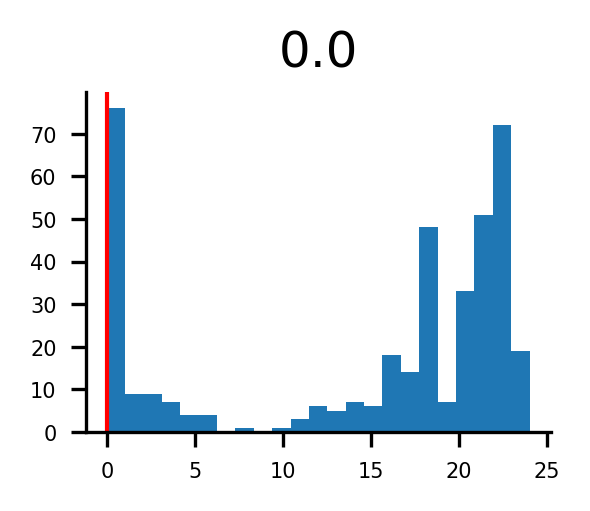

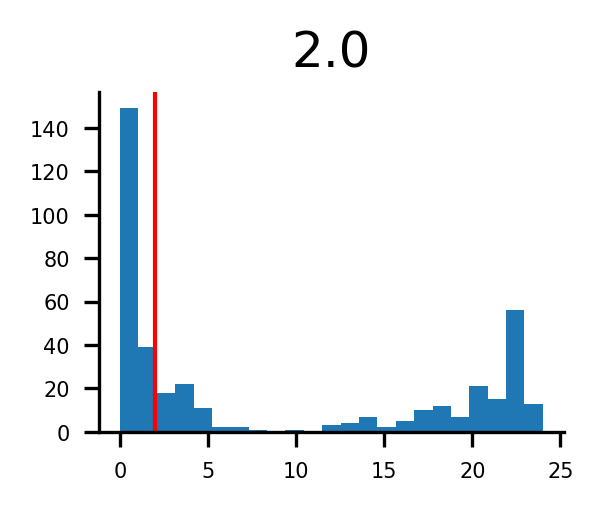

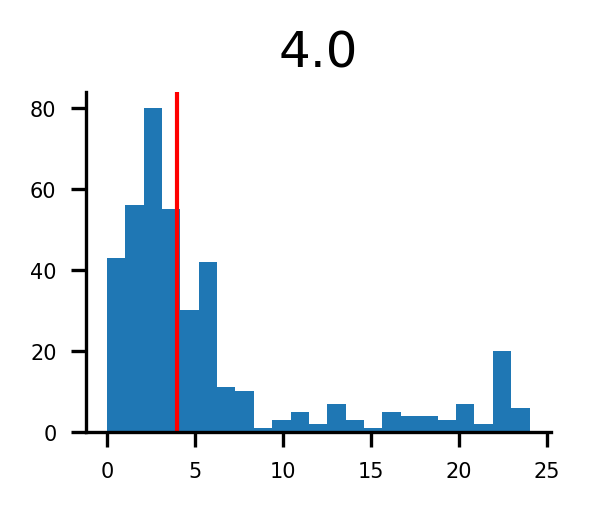

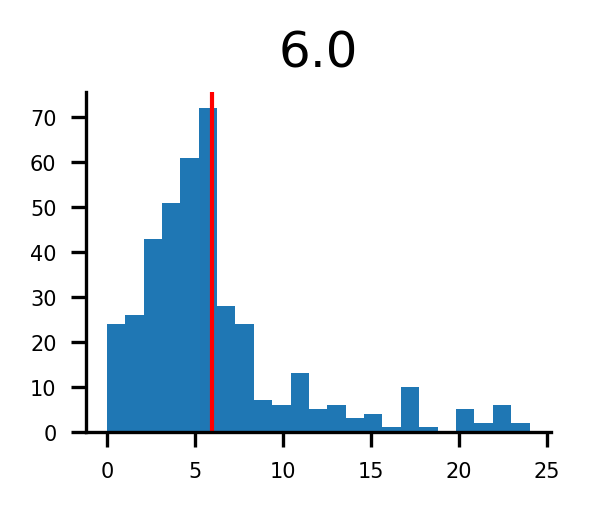

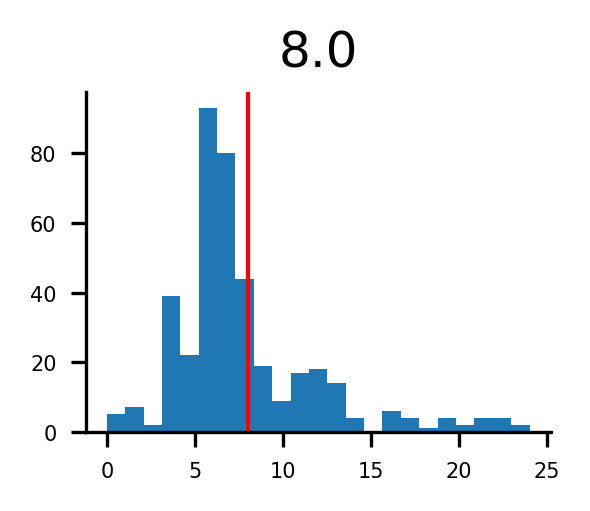

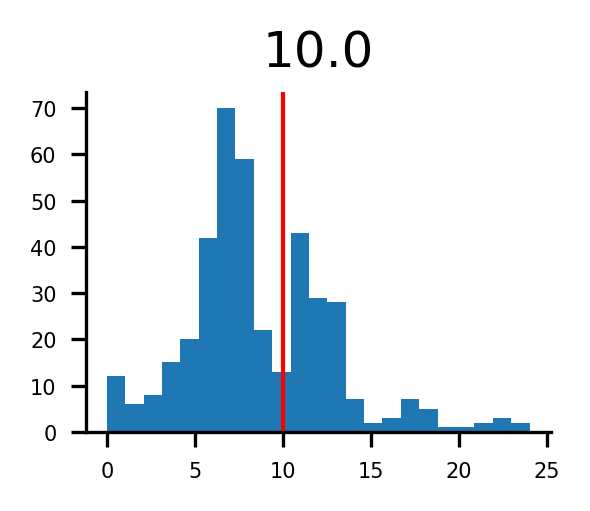

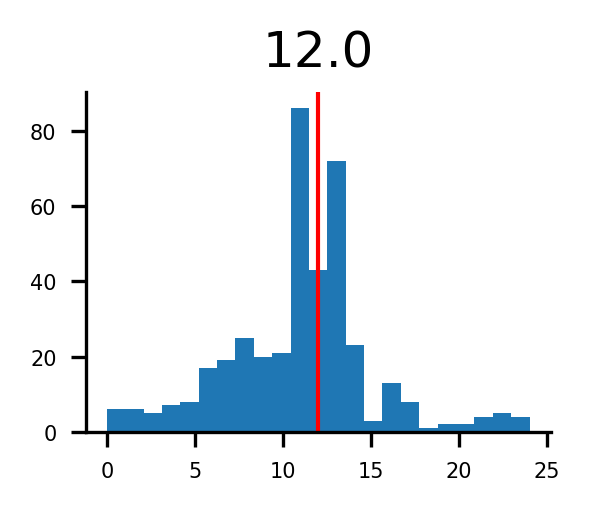

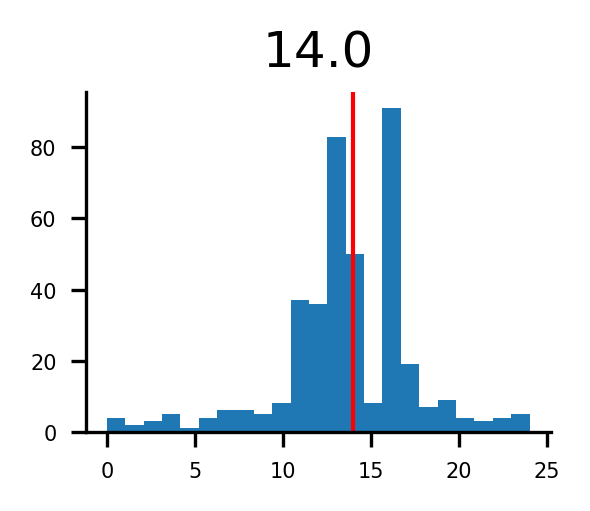

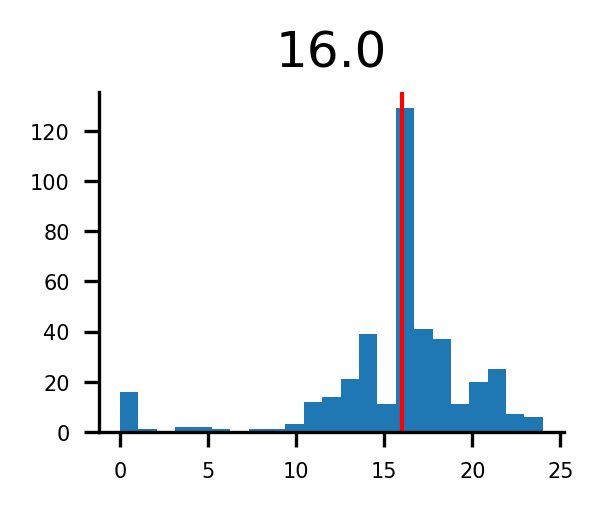

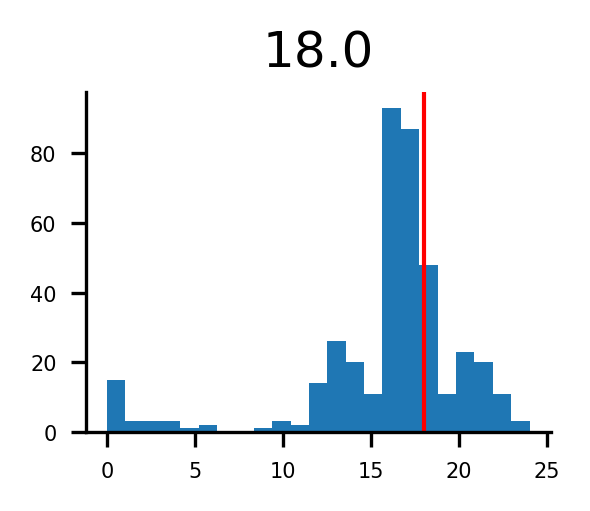

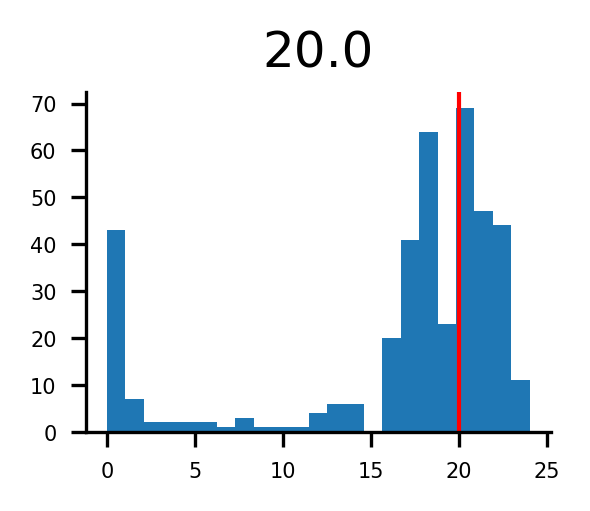

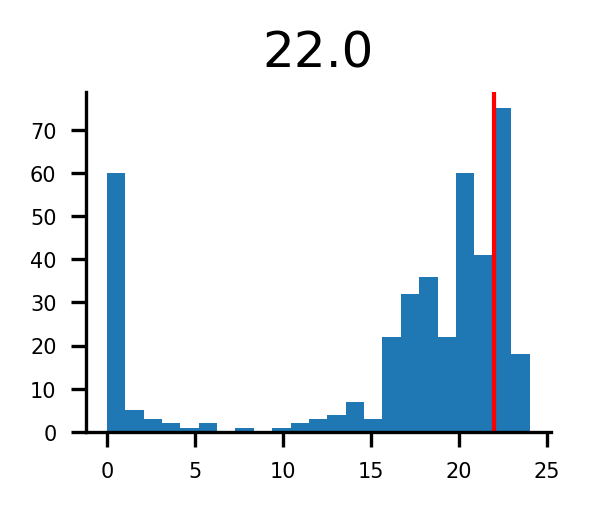

In [140]:
# --- LOOK AT THE MAP'S FOR EACH UNIQUE PHASE ---

unique_phases = sorted(list(adata.obs['phase'].unique()))
for phase in unique_phases:
    phase_adata = adata[adata.obs['phase'] == phase]
    
    fig, ax = plt.subplots(figsize = (2,1.5),dpi=300)
    plt.hist((phase_adata.obs['map_phase'] / np.pi) * 12.0,bins=np.linspace(0,24,24))
    plt.title((phase / np.pi) * 12.0)
    plt.axvline(x = (phase / np.pi) * 12.0,c='r')
    sns.despine()
    plt.show()



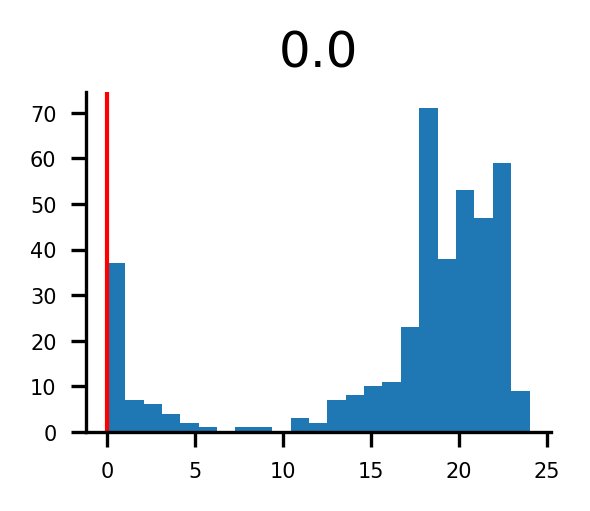

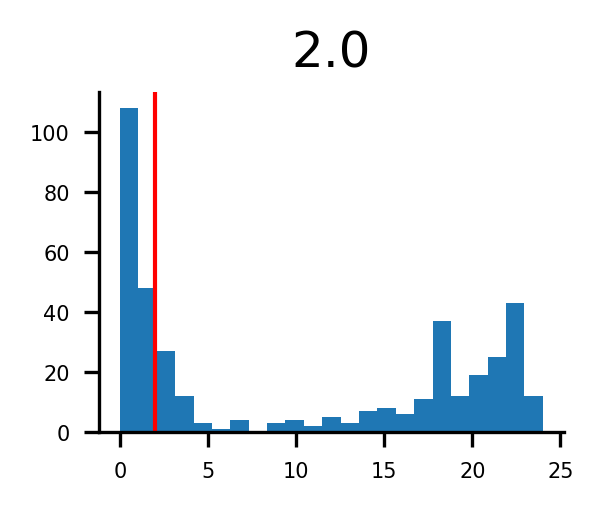

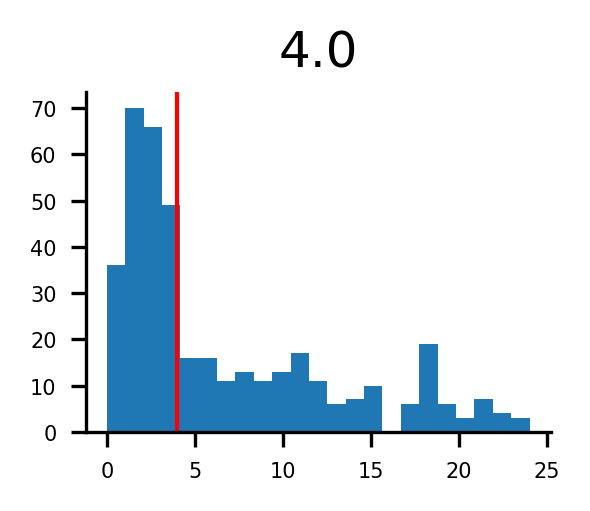

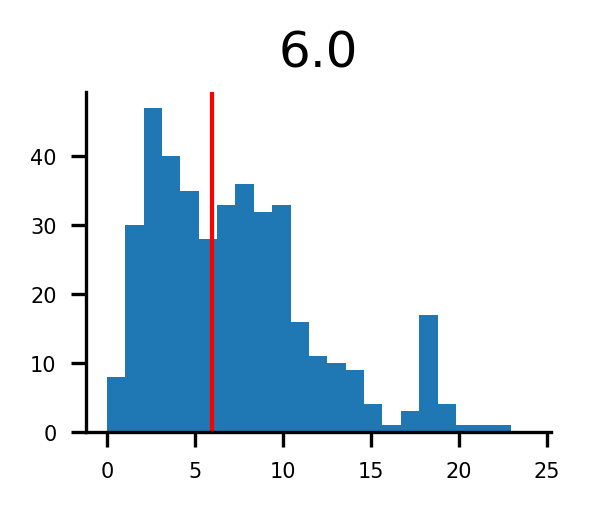

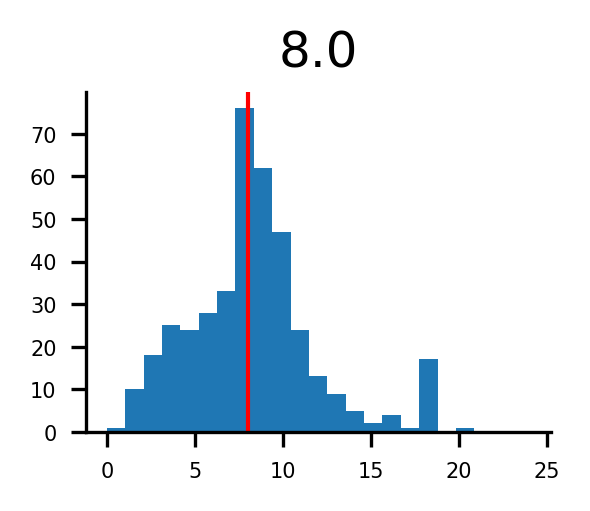

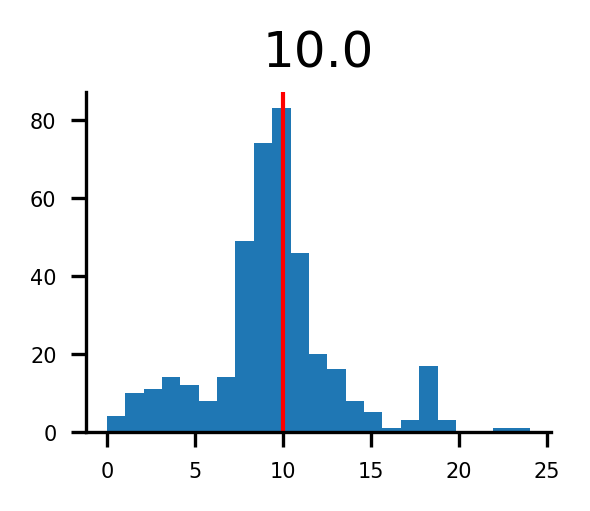

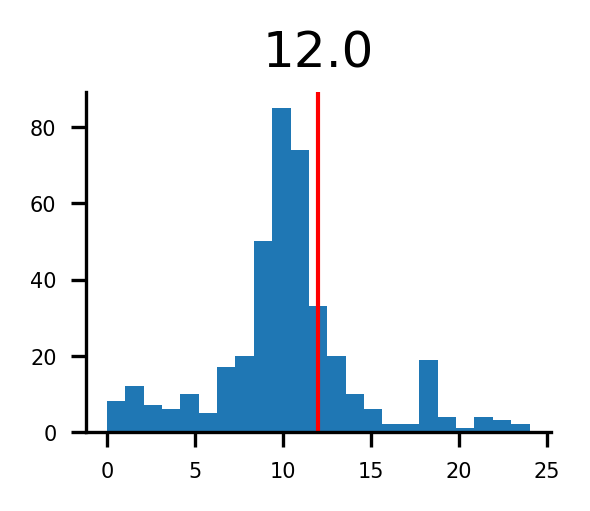

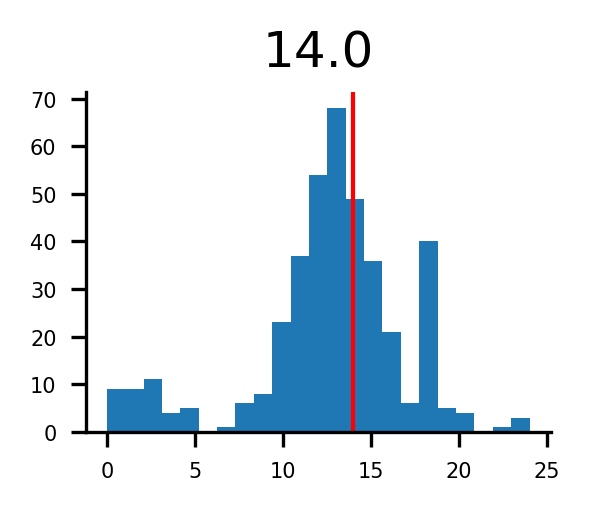

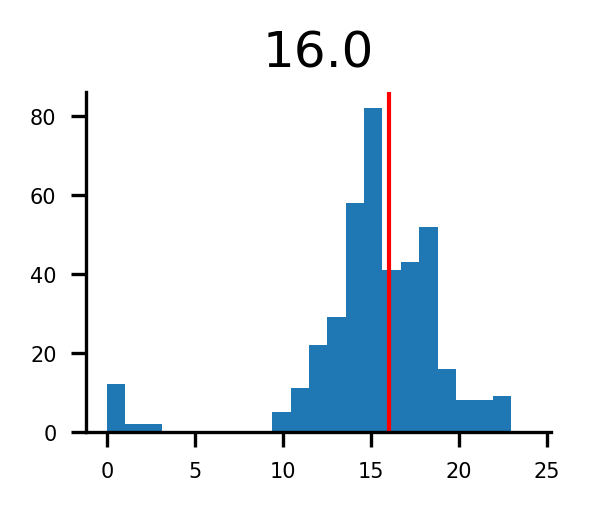

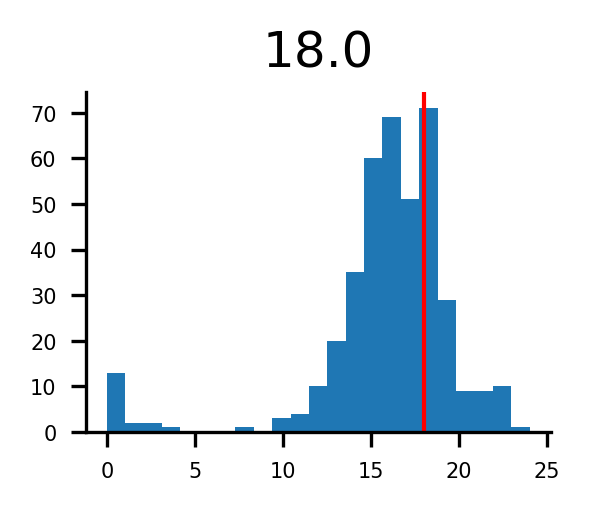

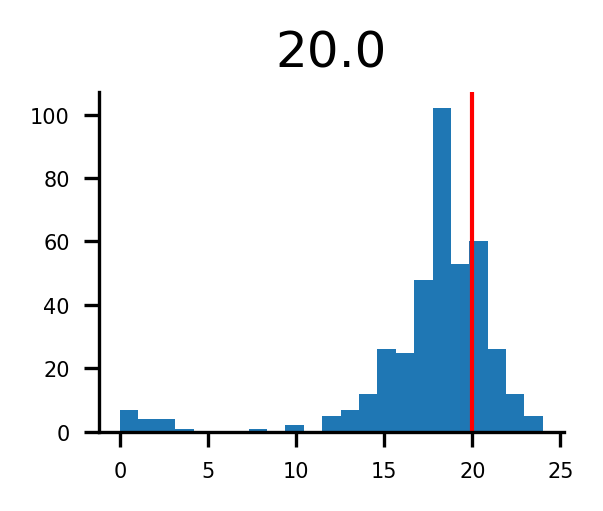

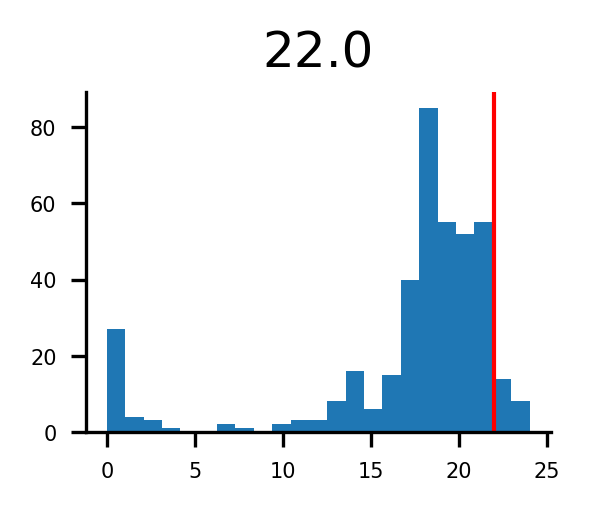

In [141]:
# --- LOOK AT THE MAP'S FOR EACH UNIQUE PHASE ASSOCIATED JUST WITH THE CLOCK ONLY ---

adata.obs['clock_map_phase'] = clock_posterior_obj.map_phase.numpy()



unique_phases = sorted(list(adata.obs['phase'].unique()))
for phase in unique_phases:
    phase_adata = adata[adata.obs['phase'] == phase]
    
    fig, ax = plt.subplots(figsize = (2,1.5),dpi=300)
    plt.hist((phase_adata.obs['clock_map_phase'] / np.pi) * 12.0,bins=np.linspace(0,24,24))
    plt.title((phase / np.pi) * 12.0)
    plt.axvline(x = (phase / np.pi) * 12.0,c='r')
    sns.despine()
    plt.show()



In [142]:
# --- COMPUTE THE ERRORS FOR BOTH ---

import sys
sys.path.insert(0,'/users/benauerbach/desktop/sc_phase_inference/paper_figures')
import fig_utils

# decide whether or not to optimally shift
opt_shift_preds = True

# get np arrays
de_novo_and_clock_map_phase = np.array(adata.obs['map_phase'])
clock_map_phase = np.array(adata.obs['clock_map_phase'])

# optimally shift is specifed
if opt_shift_preds:
    de_novo_and_clock_map_phase,de_novo_and_clock_min_error_shift_radians = fig_utils.get_optimal_predicted_phase_when_reference_gene_unknown(true_phase = np.array(adata.obs['phase']),
                                                            predicted_phase = de_novo_and_clock_map_phase,
                                                            viz = False)
    clock_map_phase,clock_min_error_shift_radians = fig_utils.get_optimal_predicted_phase_when_reference_gene_unknown(true_phase = np.array(adata.obs['phase']),
                                                            predicted_phase = clock_map_phase,
                                                            viz = False)

# compute the de novo and clock error
de_novo_and_clock_radian_error = fig_utils.compute_angle_dif(np.array(adata.obs['phase']),de_novo_and_clock_map_phase)
clock_radian_error = fig_utils.compute_angle_dif(np.array(adata.obs['phase']),clock_map_phase)
de_novo_and_clock_hour_error = (de_novo_and_clock_radian_error / np.pi) * 12.0
clock_hour_error = (clock_radian_error / np.pi) * 12.0
    
    
    


In [143]:
# # --- GET THE SHIFTED POSTERIOR DISTRIBUTIONS ---


de_novo_and_clock_posterior_obj = tempo.cell_posterior.ThetaPosteriorDist(posterior_likelihood.detach())
de_novo_and_clock_posterior_shifted = de_novo_and_clock_posterior_obj.get_shifted_posterior_likelihood(de_novo_and_clock_min_error_shift_radians)
clock_posterior_shifted = clock_posterior_obj.get_shifted_posterior_likelihood(clock_min_error_shift_radians)

de_novo_and_clock_posterior_obj_shifted = tempo.cell_posterior.ThetaPosteriorDist(de_novo_and_clock_posterior_shifted.detach())
clock_posterior_obj_shifted = tempo.cell_posterior.ThetaPosteriorDist(clock_posterior_shifted.detach())







printing radian shift discretized: 23.0
printing radian shift discretized: 23.0


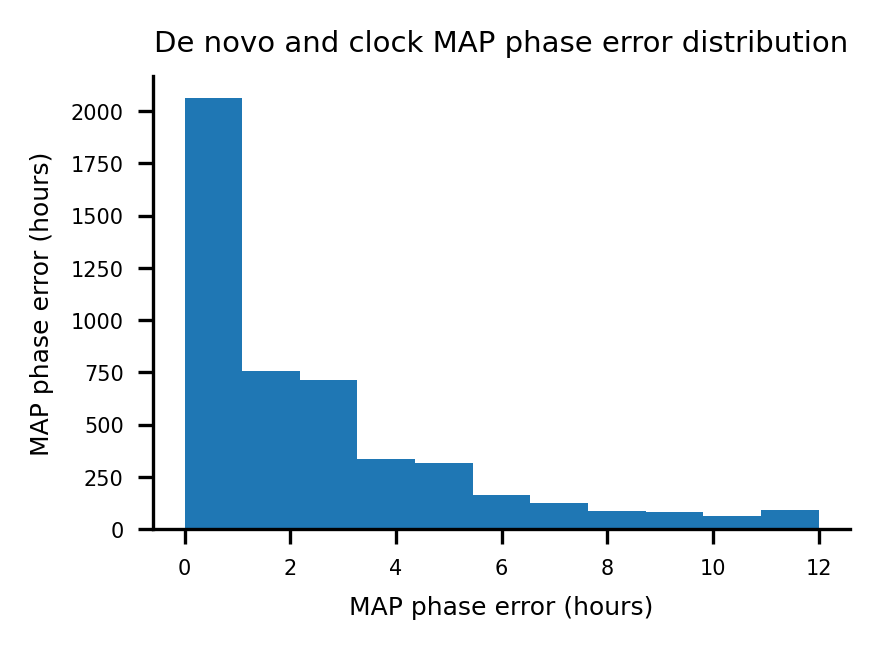

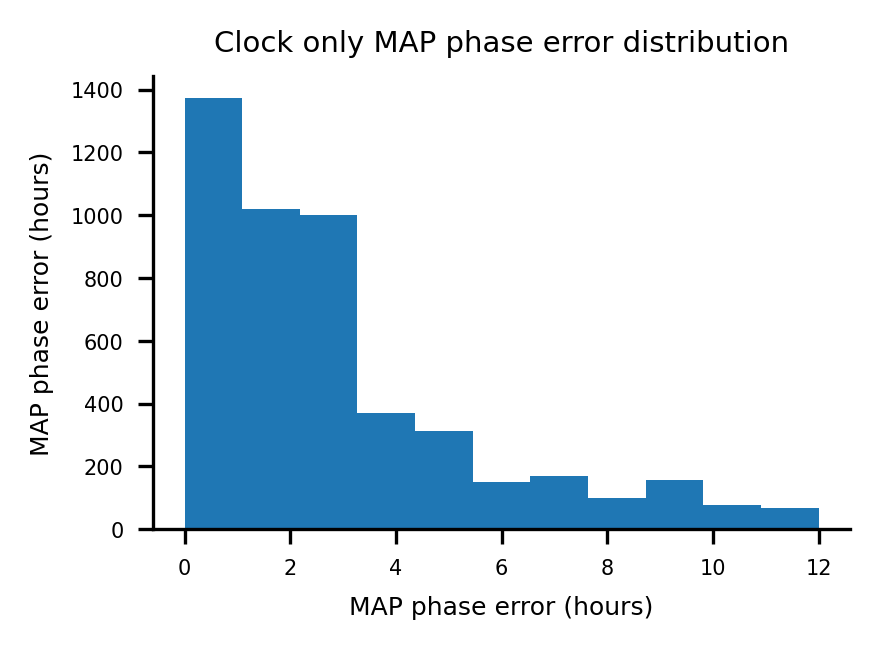

In [144]:
# --- VIZ HISTOGRAMS OF THE MAP ERRORS ---


fig, ax = plt.subplots(figsize = (3,2),dpi=300)
plt.hist(de_novo_and_clock_hour_error,bins=np.linspace(0,12,12))
plt.xlabel("MAP phase error (hours)")
plt.ylabel("MAP phase error (hours)")
plt.title("De novo and clock MAP phase error distribution",fontsize=7)
sns.despine()
plt.show()


fig, ax = plt.subplots(figsize = (3,2),dpi=300)
plt.hist(clock_hour_error,bins=np.linspace(0,12,12))
plt.xlabel("MAP phase error (hours)")
plt.ylabel("MAP phase error (hours)")
plt.title("Clock only MAP phase error distribution",fontsize=7)
sns.despine()
plt.show()



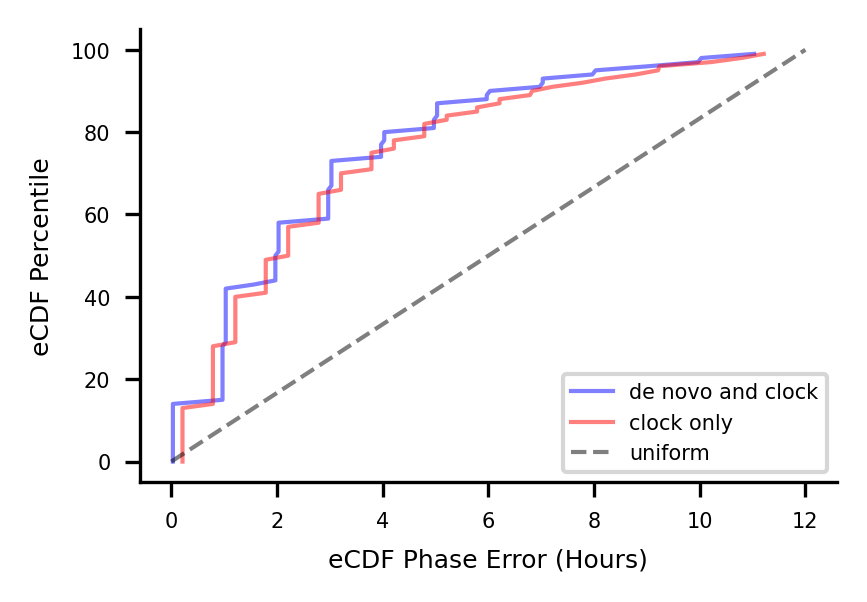

In [145]:
# --- VIZ THE eCDF's FOR THE MAP ERROR ---


percentile_vec = np.arange(0,100,1)
de_novo_and_clock_percentile_vals = np.percentile(de_novo_and_clock_hour_error,percentile_vec)
clock_percentile_vals = np.percentile(clock_hour_error,percentile_vec)

fig, ax = plt.subplots(figsize = (3,2),dpi=300)
plt.plot(de_novo_and_clock_percentile_vals,percentile_vec,label='de novo and clock',c='b',alpha=0.5)
plt.plot(clock_percentile_vals,percentile_vec,label='clock only',c='r',alpha=0.5)
plt.plot(np.linspace(0,12,100),np.linspace(0,100,100),label='uniform',c='k',alpha=0.5,linestyle='--')
sns.despine()
plt.legend()
plt.ylabel("eCDF Percentile")
plt.xlabel("eCDF Phase Error (Hours)")
plt.show()






In [146]:
# --- COMPUTE THE LIKELIHOOD OF THE PHASES IN THE POSTERIOR DISTRIBUTIONS ---



clock_and_de_novo_phase_log_prob = de_novo_and_clock_posterior_obj.log_prob(torch.Tensor(np.array(adata.obs['phase'])))
clock_phase_log_prob = clock_posterior_obj.log_prob(torch.Tensor(np.array(adata.obs['phase'])))

clock_and_de_novo_phase_log_prob = torch.sum(clock_and_de_novo_phase_log_prob).item()
clock_phase_log_prob = torch.sum(clock_phase_log_prob).item()


print("Likelihood of phases in clock and de novo cell phase posteriors: %s" % clock_and_de_novo_phase_log_prob)
print("Likelihood of phases in clock only cell phase posteriors: %s" % clock_phase_log_prob)








clock_and_de_novo_phase_log_prob = de_novo_and_clock_posterior_obj_shifted.log_prob(torch.Tensor(np.array(adata.obs['phase'])))
clock_phase_log_prob = clock_posterior_obj_shifted.log_prob(torch.Tensor(np.array(adata.obs['phase'])))
clock_and_de_novo_phase_log_prob = torch.sum(clock_and_de_novo_phase_log_prob).item()
clock_phase_log_prob = torch.sum(clock_phase_log_prob).item()

print("-----")


print("SHIFTED Likelihood of phases in clock and de novo cell phase posteriors: %s" % clock_and_de_novo_phase_log_prob)
print("SHIFTED Likelihood of phases in clock only cell phase posteriors: %s" % clock_phase_log_prob)







Likelihood of phases in clock and de novo cell phase posteriors: -14492.688577189336
Likelihood of phases in clock only cell phase posteriors: -13130.1455078125
-----
SHIFTED Likelihood of phases in clock and de novo cell phase posteriors: -13759.65021528233
SHIFTED Likelihood of phases in clock only cell phase posteriors: -12315.0361328125


In [147]:
# --- LOOK AT THE EVIDENCE OF THE CLOCK EXPRESSION UNDER THE PREVIOUS PHASE POSTERIOR VS. THE NEW ONE ---

num_cell_samples = 20
num_gene_samples = 20


# get theta samples from de novo and clock only
de_novo_and_clock_theta_sampled = de_novo_and_clock_posterior_obj.sample(num_cell_samples)
clock_theta_sampled = clock_posterior_obj.sample(num_cell_samples)


# get LL mat's: [num_gene_samples x num_cells x num_cell_samples x num_genes]
clock_theta_clock_ll_mat = compute_clock_ll_mat(clock_X = clock_X,
                        clock_param_dict = clock_param_dict,
                        clock_min_amp = clock_min_amp,
                        clock_max_amp = clock_max_amp,
                        log_L = log_L,
                        phases_sampled = clock_theta_sampled,
                        num_gene_samples = num_gene_samples,
                        use_nb = use_nb,
                        log_mean_log_disp_coef = log_mean_log_disp_coef)

# get clock_theta_clock_ll_mat: [num_gene_samples x num_cells x num_cell_samples x num_genes]
de_novo_and_clock_theta_clock_ll_mat = compute_clock_ll_mat(clock_X = clock_X,
                        clock_param_dict = clock_param_dict,
                        clock_min_amp = clock_min_amp,
                        clock_max_amp = clock_max_amp,
                        log_L = log_L,
                        phases_sampled = de_novo_and_clock_theta_sampled,
                        num_gene_samples = num_gene_samples,
                        use_nb = use_nb,
                        log_mean_log_disp_coef = log_mean_log_disp_coef)




# ** compute the evidence based on the clock alone estimates **
clock_theta_clock_log_evidence = torch.mean(torch.sum(torch.sum(clock_theta_clock_ll_mat,dim=1),dim=2))
de_novo_and_clock_theta_clock_log_evidence = torch.mean(torch.sum(torch.sum(de_novo_and_clock_theta_clock_ll_mat,dim=1),dim=2))



print("Clock log evidence based on phase estimates from clock alone: %s" % clock_theta_clock_log_evidence.item())
print("Clock log evidence based on phase estimates from clock and de novo: %s" % de_novo_and_clock_theta_clock_log_evidence.item())




Clock log evidence based on phase estimates from clock alone: -105639.203125
Clock log evidence based on phase estimates from clock and de novo: -106321.40625


In [148]:
# --- GET THE LOWER BOUND ON THE CLOCK EVIDENCE BASED ON THE CLOCK ALONE ---


bound_level = 1

# flatten out the clock ll: [(num_cell_samples * num_gene_samples)]
clock_ll_flat = torch.sum(torch.sum(clock_theta_clock_ll_mat,dim=1),dim=2).flatten().detach().numpy()
clock_ll_bound = np.percentile(clock_ll_flat,bound_level)

clock_ll_bound






-106444.15625

In [149]:
# --- GET THE UPPER BOUND ON THE CLOCK EVIDENCE BASED ON THE CLOCK + DE NOVO ---

de_novo_and_clock_theta_clock_ll_flat = torch.sum(torch.sum(de_novo_and_clock_theta_clock_ll_mat,dim=1),dim=2).flatten().detach().numpy()
de_novo_and_clock_theta_clock_ll_upper = np.percentile(de_novo_and_clock_theta_clock_ll_flat,100 - bound_level)

de_novo_and_clock_theta_clock_ll_upper





-105872.41882812501

In [137]:
# --- INIT ---

lr = (1e-3 + 1e-2) / 2
vi_max_epochs = 300
num_cell_samples = 5
num_gene_samples = 3


clock_param_dict = torch.load(clock_gene_unprepped_param_path)
for key, val in clock_param_dict.items():
    clock_param_dict[key] = torch.nn.Parameter(clock_param_dict[key],requires_grad=True)
clock_param_dict

{'mu_loc': Parameter containing:
 tensor([-10.5210, -10.4729, -10.7176, -10.7891,  -9.0881, -10.4756,  -9.7396,
          -8.4777,  -8.9509,  -8.9131,  -9.5458,  -8.8034,  -8.7489,  -9.8057,
          -7.8645, -10.0294,  -9.9981,  -8.5346,  -9.2803,  -9.7120,  -9.5477,
          -9.6680,  -9.1594,  -9.5441], requires_grad=True),
 'mu_log_scale': Parameter containing:
 tensor([-3.1578, -2.8992, -3.0548, -3.1216, -3.0212, -3.2083, -3.3458, -3.7547,
         -3.4437, -3.2697, -3.3542, -2.9636, -3.4102, -3.1133, -3.5492, -3.3464,
         -3.5069, -3.3208, -3.2032, -3.1482, -3.3770, -3.3113, -3.1361, -3.4837],
        requires_grad=True),
 'A_log_alpha': Parameter containing:
 tensor([ 2.8657,  0.0841,  2.5204,  2.2540,  1.6146,  0.9331,  0.5933, -0.3995,
         -0.4236, -0.4396,  3.2643,  1.9496, -0.3886,  2.2544, -0.6135,  2.5988,
          3.0666,  3.1622,  2.6100,  2.5358,  2.8041, -0.1761,  0.7905,  2.6670],
        requires_grad=True),
 'A_log_beta': Parameter containing:
 tensor([

In [138]:
# --- SEE IF CAN OPTIMIZE PARAMETERS TO IMPROVE THE LIKELIHOOD OF THE ESTIMATES ON THE CLOCK GENES ---





# ** init opt **
optimizer = torch.optim.Adam([de_novo_log_alpha,de_novo_log_beta] + list(clock_param_dict.values()), lr = lr)


# ** train **
elbo_losses, kl_losses, ll_losses = [], [], []
loss_percent_differences = []
for epoch in range(0,vi_max_epochs):
    
    print("epoch")
    print(epoch)

    # ** zero grad **
    optimizer.zero_grad()


    
    
    # ** sample gene parameters **


    # ** get associated cell phase samples **
    posterior_likelihood,_,_ = grid_sample_posterior_cell_phase(log_L,
        prior_theta_euclid_dist,
        num_grid_points = num_grid_points,
        num_gene_samples = num_gene_samples,
        clock_X = clock_X,
        clock_param_dict = clock_param_dict,
        clock_min_amp = clock_min_amp,
        clock_max_amp = clock_max_amp,
        de_novo_X = de_novo_X,
        de_novo_log_alpha = de_novo_log_alpha,
        de_novo_log_beta = de_novo_log_beta,
        de_novo_min_log_prop = de_novo_min_log_prop,
        de_novo_max_log_prop = de_novo_max_log_prop,                             
        use_nb = use_nb,
        log_mean_log_disp_coef = log_mean_log_disp_coef)
    de_novo_and_clock_posterior_obj = tempo.cell_posterior.ThetaPosteriorDist(posterior_likelihood)
    phase_samples = de_novo_and_clock_posterior_obj.rsample(num_cell_samples)

    
    
    # ** compute the likelihood mat's **

    # clock mat: [num_gene_samples x num_cells x num_cell_samples x num_genes]
    clock_ll_mat = compute_clock_ll_mat(clock_X = clock_X,
                            clock_param_dict = clock_param_dict,
                            clock_min_amp = clock_min_amp,
                            clock_max_amp = clock_max_amp,
                            log_L = log_L,
                            phases_sampled = phase_samples,
                            num_gene_samples = num_gene_samples,
                            use_nb = use_nb,
                            log_mean_log_disp_coef = log_mean_log_disp_coef)


    # [num_gene_samples x num_cells x num_cell_samples x num_genes]
    de_novo_ll_mat = compute_nonparametric_ll_mat(gene_X = de_novo_X,
                                log_L = log_L,
                                phases_sampled = phase_samples,
                                gene_log_alpha = de_novo_log_alpha,
                                gene_log_beta = de_novo_log_beta,
                                gene_min_log_prop = de_novo_min_log_prop,
                                gene_max_log_prop = de_novo_max_log_prop,
                                num_gene_samples = num_gene_samples,
                                use_nb = use_nb,
                                log_mean_log_disp_coef = log_mean_log_disp_coef)
    
    # concat
    ll_cell_gene_grid_sampled = torch.cat((clock_ll_mat,de_novo_ll_mat), dim=3)
    
    
    
    # ** compute KL of the gene variational distributions with their priors **


    #  de novo KL
#     de_novo_prior_gene_dist = torch.distributions.beta.Beta(torch.ones(de_novo_log_alpha.shape),torch.ones(de_novo_log_alpha.shape))
#     de_novo_gene_dist = torch.distributions.beta.Beta(torch.exp(de_novo_log_alpha),torch.exp(de_novo_log_beta))
#     de_novo_gene_kl = torch.distributions.kl_divergence(de_novo_prior_gene_dist,de_novo_gene_dist)
#     de_novo_gene_kl = torch.sum(de_novo_gene_kl,dim=0)

    # clock KL
    
    
    
    # ** TEMP **
    de_novo_gene_kl = torch.zeros((clock_X.shape[1] + de_novo_X.shape[1]))
    
    
    # ** compute the expected LL for each gene **
    gene_e_ll = torch.mean(torch.flatten(torch.sum(ll_cell_gene_grid_sampled,dim=1),start_dim=0,end_dim=1),dim=0)
    
    
    # ** compute the gene ELBO's **
    gene_elbo = de_novo_gene_kl - gene_e_ll

    
    # ** compute the penalty for being worse than the OG clock LL **
    clock_max_ll = torch.max(torch.sum(torch.sum(clock_ll_mat,dim=1),dim=2))
    clock_ll_change = clock_ll_bound - clock_max_ll
    clock_ll_change_penalty = torch.nn.ReLU()(clock_ll_change)
    clock_ll_change_penalty = (1 + clock_ll_change_penalty)



    # ** compute the loss*
    # loss = -1 * torch.mean(torch.sum(torch.sum(clock_theta_clock_ll_mat,dim=1),dim=2))
    loss = torch.mean(gene_elbo)
    loss = clock_ll_change_penalty * loss
    

    # ** pass backward **
    loss.backward()

    # ** step **
    optimizer.step()

#     # ** write parameters at epoch to file **
#     fileout = "%s/params/%s.pt" % (flat_est_folder_out,epoch)
#     param_dict = {"gene_log_alpha" : flat_gene_log_alpha, "gene_log_beta" : flat_gene_log_beta}
#     torch.save(param_dict, fileout)


    # ** print loss **
    # if vi_print_epoch_loss:
    # print("Iter: %s; ELBO %s: E[LL]: %s; KL: %s" % (epoch, round(loss.item(),3), round(torch.mean(gene_mc_ll).item(),3), round(torch.mean(gene_kl).item(),3)))
    print("Iter: %s; Loss: %s; Clock penalty: %s" % (epoch, round(loss.item(),3), round(clock_ll_change_penalty.item())))

#     # ** calculate loss percentage improvement **
#     if epoch >= 2 * vi_improvement_window:
#         loss_percent_improvement =  1 - (np.mean(elbo_losses[epoch-vi_improvement_window:]) / np.mean(elbo_losses[epoch - (2 * vi_improvement_window):epoch-vi_improvement_window]))
#         loss_percent_differences.append(loss_percent_improvement)
#         if vi_print_epoch_loss:
#             print("Improvement: %s" % loss_percent_improvement)

#     # ** check if we should stop training **
#     if (epoch >= 2 * vi_improvement_window) and (loss_percent_improvement <= vi_convergence_criterion):
#         print("Loss converged and stopping")
#         break

        
        
        



epoch
0
Iter: 0; Loss: 5887.3; Clock penalty: 1
epoch
1
Iter: 1; Loss: 737318.125; Clock penalty: 125
epoch
2
Iter: 2; Loss: 5876.66; Clock penalty: 1
epoch
3
Iter: 3; Loss: 5873.822; Clock penalty: 1
epoch
4
Iter: 4; Loss: 5880.54; Clock penalty: 1
epoch
5
Iter: 5; Loss: 5876.845; Clock penalty: 1
epoch
6
Iter: 6; Loss: 5880.021; Clock penalty: 1
epoch
7
Iter: 7; Loss: 5881.353; Clock penalty: 1
epoch
8
Iter: 8; Loss: 5875.528; Clock penalty: 1
epoch
9
Iter: 9; Loss: 5882.607; Clock penalty: 1
epoch
10
Iter: 10; Loss: 5875.725; Clock penalty: 1
epoch
11
Iter: 11; Loss: 5881.617; Clock penalty: 1
epoch
12
Iter: 12; Loss: 5876.408; Clock penalty: 1
epoch
13
Iter: 13; Loss: 5882.45; Clock penalty: 1
epoch
14
Iter: 14; Loss: 5880.424; Clock penalty: 1
epoch
15
Iter: 15; Loss: 5877.866; Clock penalty: 1
epoch
16
Iter: 16; Loss: 5876.413; Clock penalty: 1
epoch
17
Iter: 17; Loss: 5882.354; Clock penalty: 1
epoch
18
Iter: 18; Loss: 5880.47; Clock penalty: 1
epoch
19
Iter: 19; Loss: 5886.267;

KeyboardInterrupt: 